Pollutant classes: ['CO', 'Dust', 'NO2', 'O3', 'PM10', 'PM2.5', 'SO2']
Class distribution:
dominant_pollutant
O3       18479
PM2.5     3853
PM10      2793
SO2       1773
Dust      1614
NO2        382
CO          93
Name: count, dtype: int64

Features: 39 | Samples: 28987
Train: 23189 | Test: 5798
[0]	validation_0-mlogloss:1.81969
[100]	validation_0-mlogloss:0.15846
[200]	validation_0-mlogloss:0.08855
[300]	validation_0-mlogloss:0.07219
[400]	validation_0-mlogloss:0.06573
[499]	validation_0-mlogloss:0.06237

══ XGBOOST CLASSIFIER RESULTS ══
Accuracy  : 0.9731 (97.3%)
Macro F1  : 0.9554

Detailed Report:
              precision    recall  f1-score   support

          CO       1.00      1.00      1.00        18
        Dust       0.92      0.98      0.95       323
         NO2       0.85      0.96      0.90        76
          O3       1.00      0.98      0.99      3696
        PM10       0.92      0.95      0.94       559
       PM2.5       0.95      0.97      0.96       771
         SO

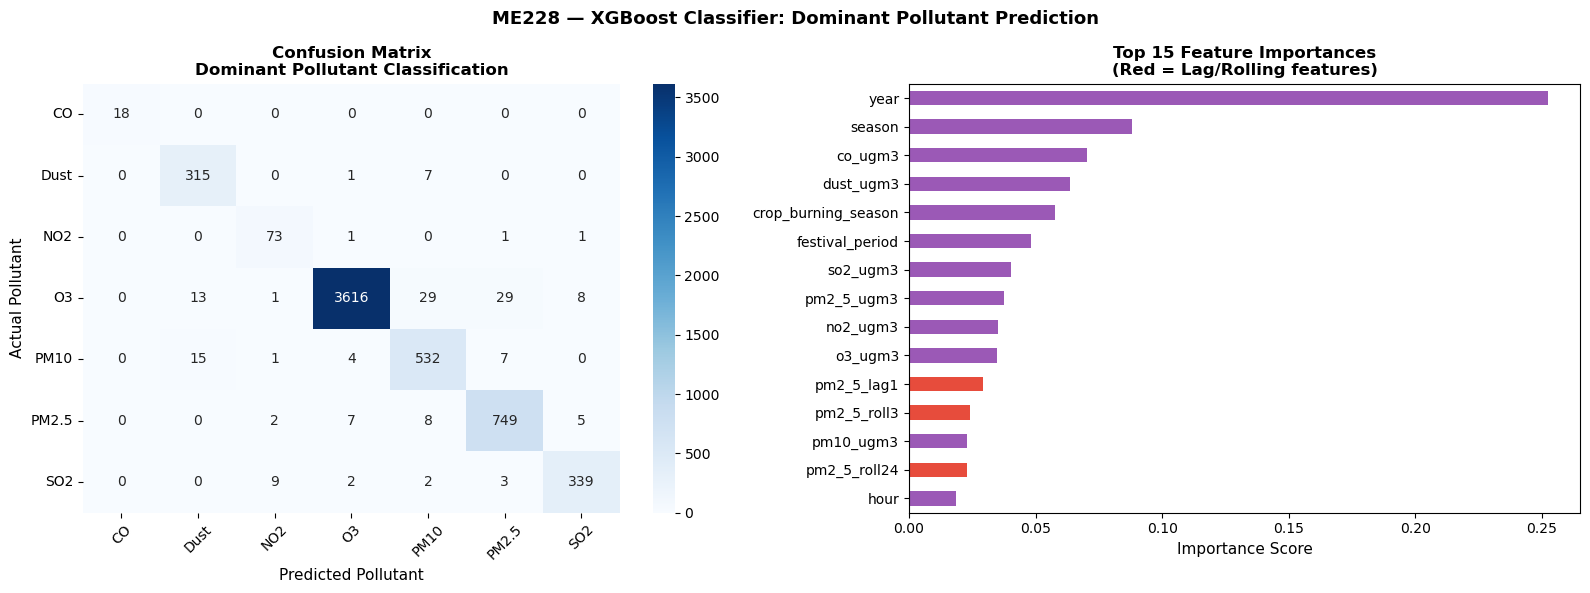

Plot saved as ME228_XGBoost_Classifier.png
Classifier saved as xgboost_classifier.pkl
Pollutant encoder saved as pollutant_encoder.pkl


In [1]:
import pandas as pd
import numpy as np
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

df = pd.read_csv('Featured_Dataset.csv')

# ── ENCODE CATEGORICALS ──
le_season = LabelEncoder()
df['season'] = le_season.fit_transform(df['season'])

bool_cols = ['is_weekend', 'is_raining', 'heavy_rain', 'festival_period', 'crop_burning_season']
for col in bool_cols:
    df[col] = df[col].astype(int)

# ── ENCODE TARGET (dominant_pollutant) ──
le_pollutant = LabelEncoder()
df['dominant_pollutant_encoded'] = le_pollutant.fit_transform(df['dominant_pollutant'])
print("Pollutant classes:", list(le_pollutant.classes_))
print("Class distribution:")
print(df['dominant_pollutant'].value_counts())

# ── FEATURES & TARGET ──
drop_cols = ['datetime', 'aqi_category', 'pm25_category_india',
             'dominant_pollutant', 'humidity_category', 'wind_category', 'time_of_day']
X = df.drop(columns=drop_cols + ['AQI', 'dominant_pollutant_encoded'])
y = df['dominant_pollutant_encoded']

print(f"\nFeatures: {X.shape[1]} | Samples: {X.shape[0]}")

# ── TRAIN/TEST SPLIT ──
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y  # stratify keeps class balance in both splits
)
print(f"Train: {len(X_train)} | Test: {len(X_test)}")

# ── HANDLE CLASS IMBALANCE ──
# O3 = 63.7%, CO = 0.3% — we use scale_pos_weight equivalent via sample_weight
from sklearn.utils.class_weight import compute_sample_weight
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

# ── TRAIN XGBOOST CLASSIFIER ──
xgb_clf = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    eval_metric='mlogloss'
)

xgb_clf.fit(X_train, y_train,
            sample_weight=sample_weights,
            eval_set=[(X_test, y_test)],
            verbose=100)

# ── EVALUATE ──
y_pred = xgb_clf.predict(X_test)

acc    = accuracy_score(y_test, y_pred)
f1     = f1_score(y_test, y_pred, average='macro')
labels = list(le_pollutant.classes_)

print("\n══ XGBOOST CLASSIFIER RESULTS ══")
print(f"Accuracy  : {acc:.4f} ({acc*100:.1f}%)")
print(f"Macro F1  : {f1:.4f}")
print("\nDetailed Report:")
print(classification_report(y_test, y_pred, target_names=labels))

# ── PLOT 1: Confusion Matrix ──
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels, ax=axes[0])
axes[0].set_xlabel('Predicted Pollutant', fontsize=11)
axes[0].set_ylabel('Actual Pollutant', fontsize=11)
axes[0].set_title('Confusion Matrix\nDominant Pollutant Classification', fontsize=12, fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)
axes[0].tick_params(axis='y', rotation=0)

# ── PLOT 2: Feature Importance ──
feat_imp = pd.Series(xgb_clf.feature_importances_, index=X.columns)
feat_imp = feat_imp.sort_values(ascending=True).tail(15)
colors = ['#e74c3c' if 'lag' in i or 'roll' in i else '#9b59b6' for i in feat_imp.index]
feat_imp.plot(kind='barh', ax=axes[1], color=colors)
axes[1].set_title('Top 15 Feature Importances\n(Red = Lag/Rolling features)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Importance Score', fontsize=11)

plt.suptitle('ME228 — XGBoost Classifier: Dominant Pollutant Prediction', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('ME228_XGBoost_Classifier.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved as ME228_XGBoost_Classifier.png")

# ── SAVE ──
joblib.dump(xgb_clf, 'xgboost_classifier.pkl')
joblib.dump(le_pollutant, 'pollutant_encoder.pkl')
print("Classifier saved as xgboost_classifier.pkl")
print("Pollutant encoder saved as pollutant_encoder.pkl")